# 🇪🇬 Egyptian ID OCR — Notebook: Two-Stage Detection with NASO7Y Models

This notebook demonstrates the **two-stage YOLO detection pipeline** using NASO7Y pre-trained models with automatic class mapping translation.

**Pipeline:**
```
Full Image → Card Detection → Card Crop → Field Detection → Field Crops → OCR
```

**Input**: Raw ID card images  
**Output**: Cropped field images ready for OCR

## 📊 Full Dataset Results (Already Processed)

The full dataset has been processed with this pipeline:

| Split | Images | Successful | Field Crops |
|-------|--------|------------|-------------|
| Train | 15,669 | 11,415 (72.9%) | 54,362 |
| Valid | 948 | 670 (70.7%) | 3,131 |
| Test | 103 | 39 (37.9%) | 192 |
| **TOTAL** | **16,720** | **12,124 (72.5%)** | **57,685** |

**Processing Speed:** 81.2 images/second (0.01s per image)

**Output Files:**
- Cropped fields: `rec/images/two_stage/`
- Metadata: `crops_metadata_two_stage.csv`

## 1. Setup Environment


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display, Image as IPImage

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

print(f"📂 Project root: {ROOT}")

📂 Project root: /home/think/project/egyption_id_ready


/home/think/project/egyption_id_ready/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Detection Models


In [2]:
from src.card_detector import CardDetector, load_card_detector

# Initialize two-stage detector
detector = load_card_detector(
    card_model_path=str(ROOT / "weights" / "card_detection.pt"),
    field_model_path=str(ROOT / "weights" / "field_detection.pt"),
)

print("✅ Two-stage detector loaded successfully!")
print()
print("📋 Model classes:")
print("   Card Detection: 8 corner/edge classes")
print("   Field Detection: 31 classes (12 valid for OCR)")

✅ Card detection model loaded: /home/think/project/egyption_id_ready/weights/card_detection.pt
✅ Field detection model loaded: /home/think/project/egyption_id_ready/weights/field_detection.pt
✅ Two-stage detector loaded successfully!

📋 Model classes:
   Card Detection: 8 corner/edge classes
   Field Detection: 31 classes (12 valid for OCR)


## 3. Test on Single Image


📷 Input image: 416x416


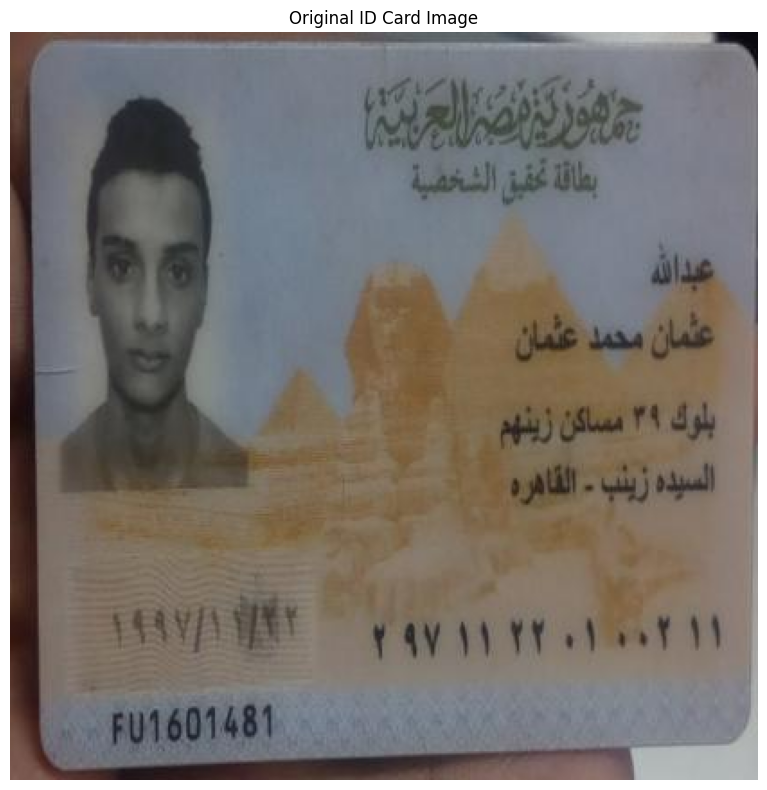

In [3]:
# Load a test image
test_image_path = ROOT / "train" / "images" / "006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.1392ac8180bd85b549b03f2d8528da26.jpg"
image = cv2.imread(str(test_image_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"📷 Input image: {image.shape[1]}x{image.shape[0]}")

# Display original image
plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.title("Original ID Card Image")
plt.axis('off')
plt.tight_layout()
plt.show()

### 3.1 Run Two-Stage Detection (NASO7Y Format)


In [4]:
# Run detection - NASO7Y format
card_crop, fields = detector.detect_full(image, translate_to_project=False)

print(f"✂️  Card crop: {card_crop.shape[1]}x{card_crop.shape[0]}")
print(f"📋 Fields detected: {len(fields)}")
print()
print("Fields (NASO7Y format):")
for field_name, (crop, conf) in fields.items():
    print(f"   - {field_name:15s}: {crop.shape[1]}x{crop.shape[0]} (conf: {conf:.2f})")

✂️  Card crop: 396x397
📋 Fields detected: 7

Fields (NASO7Y format):
   - photo          : 106x226 (conf: 0.92)
   - firstName      : 43x36 (conf: 0.91)
   - dob            : 134x70 (conf: 0.91)
   - lastName       : 115x35 (conf: 0.89)
   - address        : 124x66 (conf: 0.89)
   - nid            : 200x36 (conf: 0.88)
   - serial         : 95x32 (conf: 0.86)


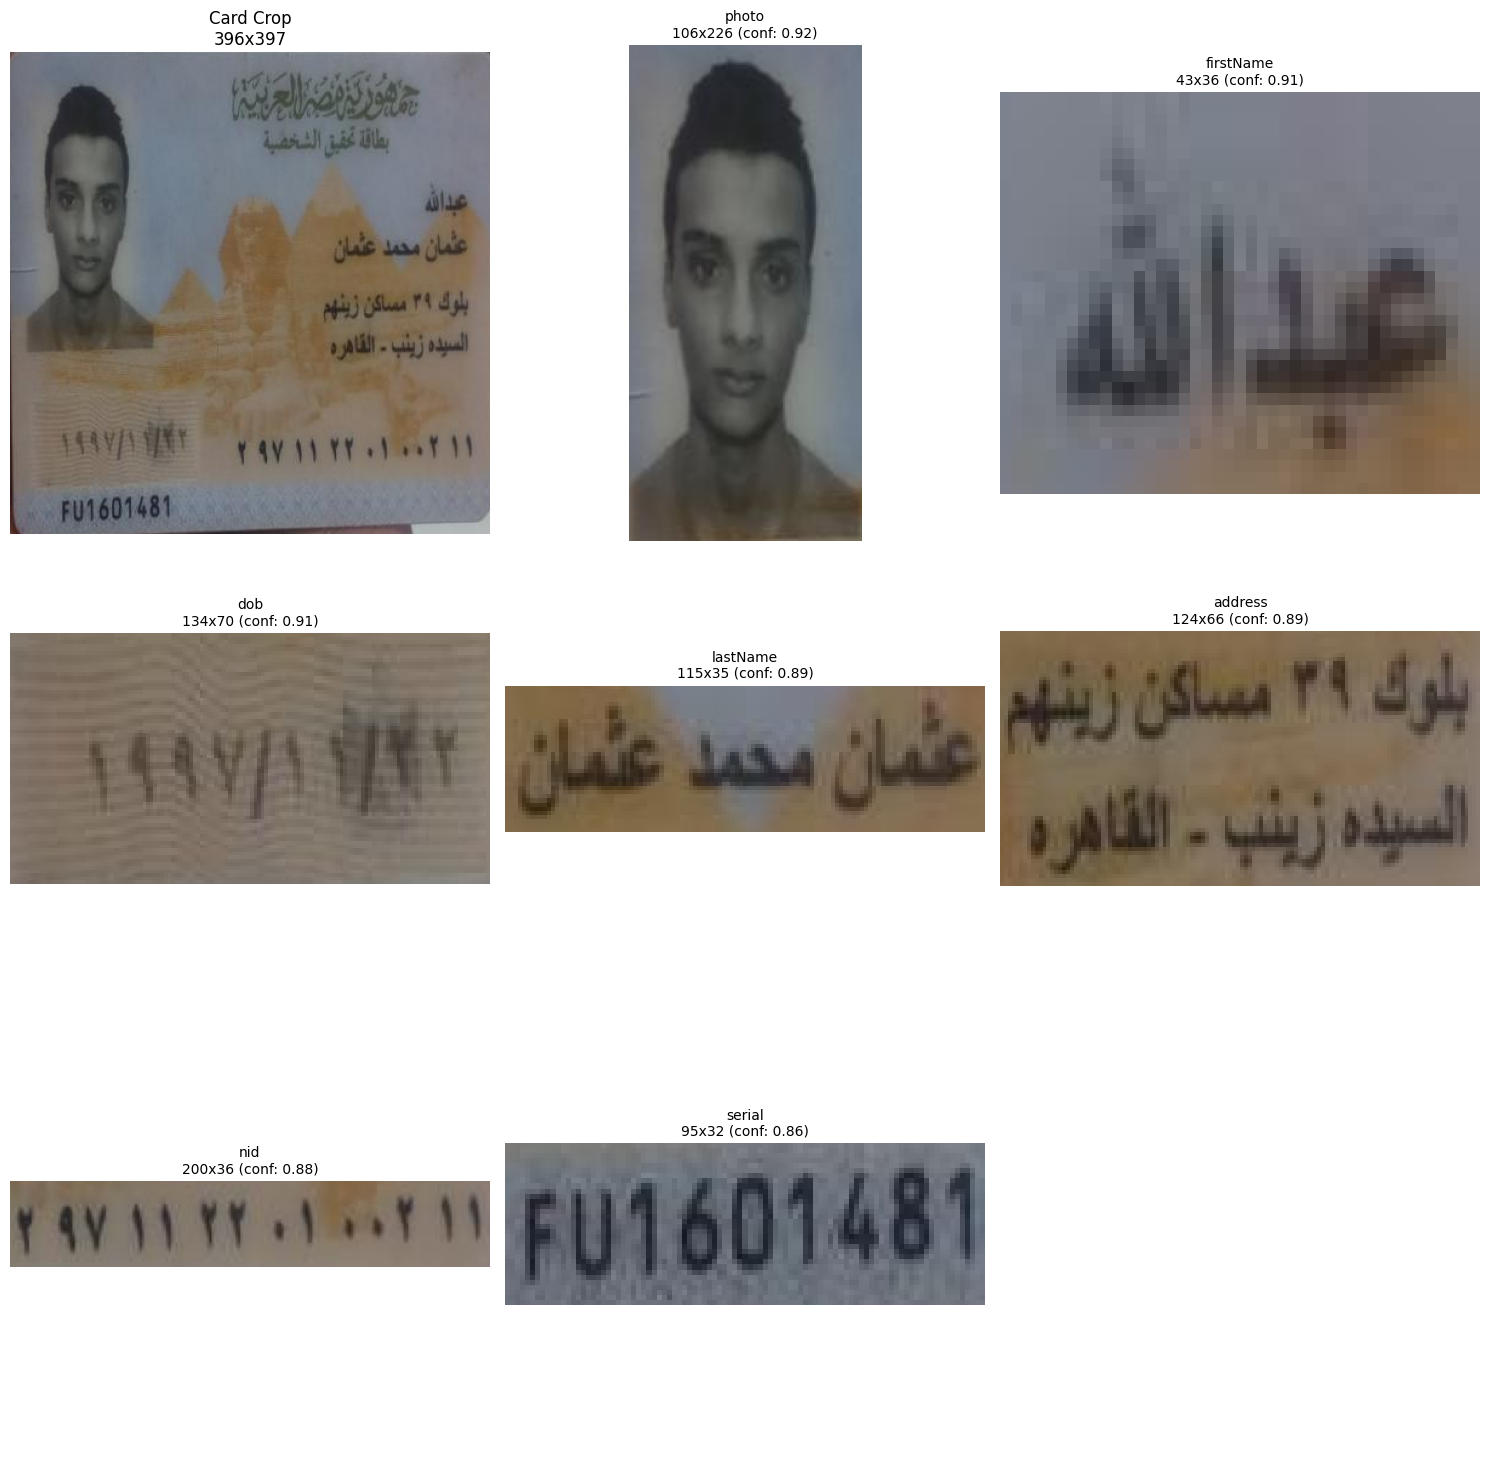

In [5]:
# Display card crop and detected fields
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Card crop
card_rgb = cv2.cvtColor(card_crop, cv2.COLOR_BGR2RGB)
axes[0].imshow(card_rgb)
axes[0].set_title(f"Card Crop\n{card_crop.shape[1]}x{card_crop.shape[0]}", fontsize=12)
axes[0].axis('off')

# Field crops
for idx, (field_name, (crop, conf)) in enumerate(fields.items(), start=1):
    if idx > 8:  # Limit to 8 fields
        break
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(crop_rgb)
    axes[idx].set_title(f"{field_name}\n{crop.shape[1]}x{crop.shape[0]} (conf: {conf:.2f})", fontsize=10)
    axes[idx].axis('off')

# Hide remaining axes
for idx in range(len(fields) + 1, 9):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 3.2 Run Two-Stage Detection (Project Format - Translated)


In [6]:
# Run detection - Project format (translated)
card_crop, fields = detector.detect_full(image, translate_to_project=True)

print(f"✂️  Card crop: {card_crop.shape[1]}x{card_crop.shape[0]}")
print(f"📋 Fields detected: {len(fields)}")
print()
print("Fields (Project format - translated):")
for field_name, (crop, conf) in fields.items():
    print(f"   - {field_name:15s}: {crop.shape[1]}x{crop.shape[0]} (conf: {conf:.2f})")

✂️  Card crop: 396x397
📋 Fields detected: 6

Fields (Project format - translated):
   - photo          : 106x226 (conf: 0.92)
   - name           : 43x36 (conf: 0.90)
   - birth_date     : 134x70 (conf: 0.91)
   - address        : 124x66 (conf: 0.89)
   - national_id    : 200x36 (conf: 0.88)
   - serial_number  : 95x32 (conf: 0.86)


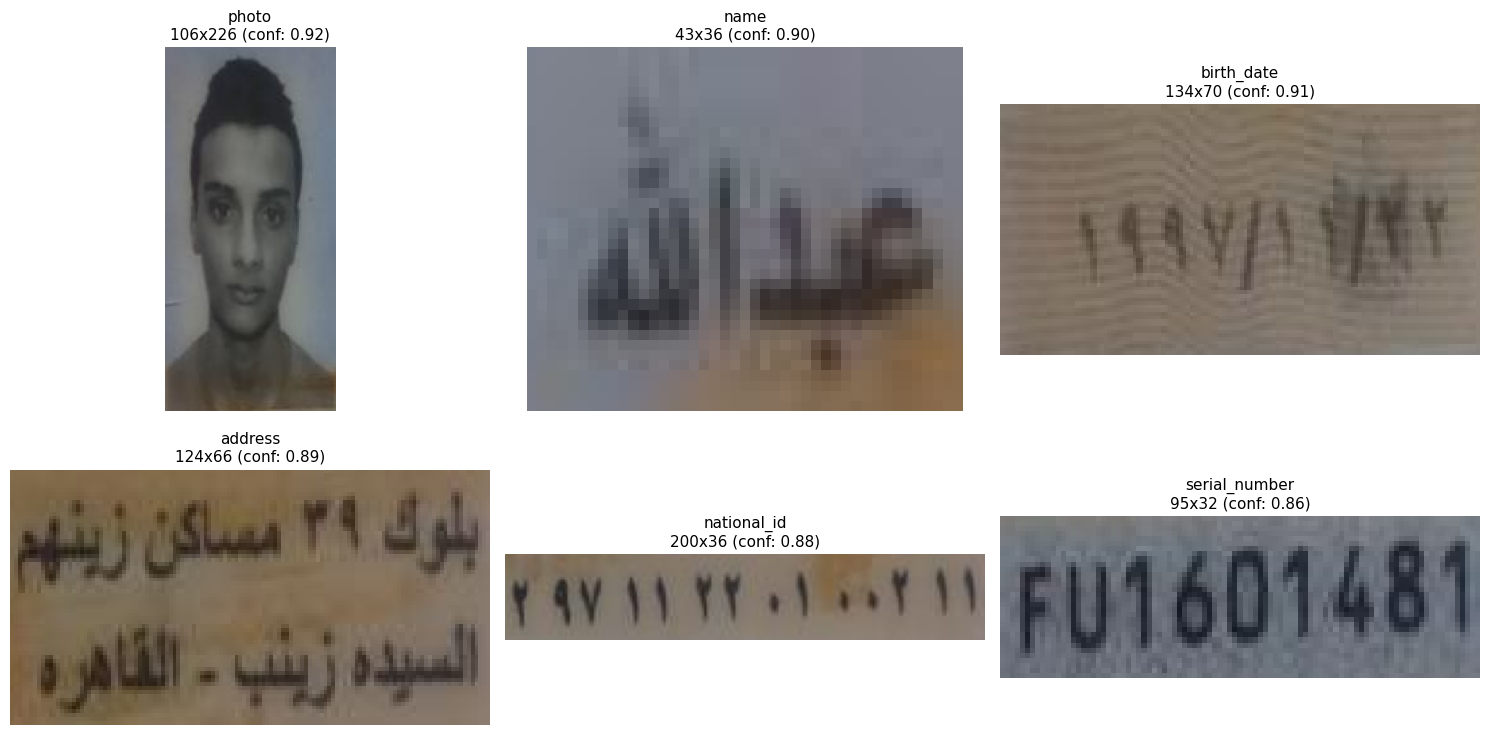

In [7]:
# Display translated field crops
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (field_name, (crop, conf)) in enumerate(fields.items()):
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(crop_rgb)
    axes[idx].set_title(f"{field_name}\n{crop.shape[1]}x{crop.shape[0]} (conf: {conf:.2f})", fontsize=11)
    axes[idx].axis('off')

# Hide remaining axes
for idx in range(len(fields), 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 3.3 Get Class Mapping


In [8]:
# Get both formats with mapping
card_crop, fields, mapping = detector.detect_full_with_mapping(image)

print("🔄 Class Mapping (NASO7Y → Project):")
print("=" * 50)
for naso7y_name, project_name in mapping.items():
    print(f"   {naso7y_name:15s} → {project_name}")

🔄 Class Mapping (NASO7Y → Project):
   photo           → photo
   firstName       → name
   dob             → birth_date
   lastName        → name
   address         → address
   nid             → national_id
   serial          → serial_number


## 4. Process Multiple Images


In [9]:
# Get list of test images
images_dir = ROOT / "train" / "images"
image_files = sorted(list(images_dir.glob("*.jpg"))[:])  # First 10 images

print(f"📋 Processing {len(image_files)} images...")

📋 Processing 15669 images...


In [10]:
# Process all images
results = []

for img_path in tqdm(image_files, desc="Processing images"):
    try:
        # Load image
        image = cv2.imread(str(img_path))
        if image is None:
            continue
        
        # Run detection
        card_crop, fields = detector.detect_full(image, translate_to_project=True)
        
        # Store results
        for field_name, (crop, conf) in fields.items():
            results.append({
                'image': img_path.name,
                'field': field_name,
                'width': crop.shape[1],
                'height': crop.shape[0],
                'confidence': round(conf, 3),
            })
    except Exception as e:
        print(f"⚠️  Error processing {img_path.name}: {e}")

# Create DataFrame
df_results = pd.DataFrame(results)
print(f"\n✅ Processed {len(df_results['image'].unique())} images")
print(f"📊 Total fields detected: {len(df_results)}")

Processing images: 100%|██████████| 15669/15669 [03:02<00:00, 85.84it/s]



✅ Processed 11414 images
📊 Total fields detected: 54353


In [11]:
# Display statistics
print("\n📊 Detection Statistics:")
print("=" * 50)
print(f"\nFields per image: {df_results.groupby('image').size().describe().to_dict()}")
print(f"\nAverage confidence by field:")
print(df_results.groupby('field')['confidence'].mean().sort_values(ascending=False).round(3))


📊 Detection Statistics:

Fields per image: {'count': 11414.0, 'mean': 4.761958997722096, 'std': 1.58969791304135, 'min': 1.0, '25%': 4.0, '50%': 5.0, '75%': 6.0, 'max': 7.0}

Average confidence by field:
field
address          0.907
birth_date       0.878
photo            0.853
national_id      0.816
name             0.804
job_title        0.791
issue_date       0.779
expiry_date      0.774
serial_number    0.747
Name: confidence, dtype: float64


## 5. Save Cropped Fields


In [12]:
# Save cropped fields for OCR
output_dir = ROOT / "rec" / "images" / "two_stage"
output_dir.mkdir(parents=True, exist_ok=True)

saved_count = 0
for img_path in tqdm(image_files[:], desc="Saving crops"):  # All images
    try:
        image = cv2.imread(str(img_path))
        card_crop, fields = detector.detect_full(image, translate_to_project=True)
        
        for field_name, (crop, conf) in fields.items():
            save_name = f"{img_path.stem}_{field_name}.jpg"
            save_path = output_dir / save_name
            cv2.imwrite(str(save_path), crop)
            saved_count += 1
    except Exception as e:
        print(f"⚠️  Error: {e}")

print(f"\n✅ Saved {saved_count} field crops to: {output_dir}")

Saving crops: 100%|██████████| 15669/15669 [03:09<00:00, 82.78it/s]


✅ Saved 54353 field crops to: /home/think/project/egyption_id_ready/rec/images/two_stage


## 6. Export Metadata CSV


In [13]:
# Create metadata DataFrame
metadata = []
for img_path in tqdm(image_files[:], desc="Creating metadata"):
    try:
        image = cv2.imread(str(img_path))
        card_crop, fields = detector.detect_full(image, translate_to_project=True)
        
        for field_name, (crop, conf) in fields.items():
            save_name = f"{img_path.stem}_{field_name}.jpg"
            metadata.append({
                'image_path': f"rec/images/two_stage/{save_name}",
                'field': field_name,
                'split': 'train',
                'orig_image': img_path.name,
                'confidence': round(conf, 3),
                'label_text': '',  # To be filled by OCR
            })
    except Exception as e:
        print(f"⚠️  Error: {e}")

# Save to CSV
df_metadata = pd.DataFrame(metadata)
metadata_path = ROOT / "crops_metadata_two_stage.csv"
df_metadata.to_csv(metadata_path, index=False, encoding='utf-8-sig')

print(f"✅ Metadata saved to: {metadata_path}")
print(f"📊 Total records: {len(df_metadata)}")
print(f"\nPreview:")
display(df_metadata.head(10))

Creating metadata: 100%|██████████| 15669/15669 [03:02<00:00, 86.04it/s]


✅ Metadata saved to: /home/think/project/egyption_id_ready/crops_metadata_two_stage.csv
📊 Total records: 54353

Preview:


,image_path,field,split,orig_image,confidence,label_text
0,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,address,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.939,
1,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,birth_date,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.937,
2,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,photo,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.915,
3,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,name,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.803,
4,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,serial_number,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.723,
5,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,national_id,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.521,
6,rec/images/two_stage/006cc843-52e3-48ab-958f-5...,photo,train,006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.13...,0.922,
7,rec/images/two_stage/006cc843-52e3-48ab-958f-5...,name,train,006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.13...,0.902,
8,rec/images/two_stage/006cc843-52e3-48ab-958f-5...,birth_date,train,006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.13...,0.913,
9,rec/images/two_stage/006cc843-52e3-48ab-958f-5...,address,train,006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.13...,0.887,


## 7. Compare: NASO7Y vs Project Format


In [14]:
from src.class_mapping import get_naso7y_valid_classes, get_project_valid_classes

print("NASO7Y Valid Classes:")
print("=" * 50)
for class_id, class_name in get_naso7y_valid_classes().items():
    print(f"   {class_id:2d}: {class_name}")

print("\n\nProject Valid Classes:")
print("=" * 50)
for class_id, class_name in get_project_valid_classes().items():
    print(f"   {class_id:2d}: {class_name}")

NASO7Y Valid Classes:
    0: address
    2: dob
    3: expiry
    4: firstName
   22: issue
   23: job
   24: lastName
   25: nid
   26: nid_back
   27: photo
   28: poe
   29: serial


Project Valid Classes:
    0: job_title
    2: expiry_date
    3: birth_date
    5: name
    6: address
    7: national_id
   12: issue_date
   23: serial_number


## 8. Summary


In [15]:
print("\n" + "=" * 60)
print("📊 TWO-STAGE DETECTION SUMMARY")
print("=" * 60)
print()
print("✅ Models Loaded:")
print("   - Card Detection: weights/card_detection.pt")
print("   - Field Detection: weights/field_detection.pt")
print()
print("✅ Images Processed:", len(df_results['image'].unique()))
print("✅ Fields Detected:", len(df_results))
print("✅ Crops Saved:", saved_count)
print()
print("📋 Field Distribution:")
field_counts = df_results['field'].value_counts()
for field, count in field_counts.items():
    print(f"   - {field:20s}: {count}")
print()
print("📂 Output:")
print(f"   - Crops: {output_dir}")
print(f"   - Metadata: {metadata_path}")
print()
print("🚀 Next Steps:")
print("   1. Review cropped fields")
print("   2. Run OCR: python scripts/label_crops.py --method qari")
print("   3. Train PaddleOCR model")
print("=" * 60)


📊 TWO-STAGE DETECTION SUMMARY

✅ Models Loaded:
   - Card Detection: weights/card_detection.pt
   - Field Detection: weights/field_detection.pt

✅ Images Processed: 11414
✅ Fields Detected: 54353
✅ Crops Saved: 54353

📋 Field Distribution:
   - name                : 9818
   - national_id         : 9745
   - address             : 9305
   - photo               : 8621
   - birth_date          : 8488
   - serial_number       : 7806
   - expiry_date         : 253
   - issue_date          : 229
   - job_title           : 88

📂 Output:
   - Crops: /home/think/project/egyption_id_ready/rec/images/two_stage
   - Metadata: /home/think/project/egyption_id_ready/crops_metadata_two_stage.csv

🚀 Next Steps:
   1. Review cropped fields
   2. Run OCR: python scripts/label_crops.py --method qari
   3. Train PaddleOCR model


## 9. Load Full Dataset Results

The full dataset has already been processed. Let's load and analyze the results.


In [16]:
# Load the processed metadata
df_full = pd.read_csv(ROOT / "crops_metadata_two_stage.csv")

print(f"📊 Full Dataset Metadata Loaded")
print(f"   Total records: {len(df_full):,}")
print(f"   Columns: {list(df_full.columns)}")
print()
print("📋 Preview:")
display(df_full.head(10))

📊 Full Dataset Metadata Loaded
   Total records: 54,353
   Columns: ['image_path', 'field', 'split', 'orig_image', 'confidence', 'label_text']

📋 Preview:


,image_path,field,split,orig_image,confidence,label_text
0,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,address,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.939,NaN
1,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,birth_date,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.937,NaN
2,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,photo,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.915,NaN
3,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,name,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.803,NaN
4,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,serial_number,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.723,NaN
5,rec/images/two_stage/-_jpeg.rf.5e7edc7a3e920e7...,national_id,train,-_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec.jpg,0.521,NaN
6,rec/images/two_stage/006cc843-52e3-48ab-958f-5...,photo,train,006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.13...,0.922,NaN
7,rec/images/two_stage/006cc843-52e3-48ab-958f-5...,name,train,006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.13...,0.902,NaN
8,rec/images/two_stage/006cc843-52e3-48ab-958f-5...,birth_date,train,006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.13...,0.913,NaN
9,rec/images/two_stage/006cc843-52e3-48ab-958f-5...,address,train,006cc843-52e3-48ab-958f-59bf42c108fd_png.rf.13...,0.887,NaN


In [17]:
# Statistics by split
print("📊 Statistics by Split:")
print("=" * 60)
for split in ['train', 'valid', 'test']:
    split_df = df_full[df_full['split'] == split]
    unique_images = split_df['orig_image'].nunique()
    total_crops = len(split_df)
    
    print(f"\n{split.upper()}:")
    print(f"   Unique images: {unique_images:,}")
    print(f"   Total crops: {total_crops:,}")
    print(f"   Avg crops per image: {total_crops / max(unique_images, 1):.2f}")
    print(f"   Avg confidence: {split_df['confidence'].mean():.3f}")
    
    # Field distribution
    print(f"   Fields:")
    field_counts = split_df['field'].value_counts()
    for field, count in field_counts.items():
        pct = count / total_crops * 100
        print(f"      - {field:20s}: {count:,} ({pct:.1f}%)")

📊 Statistics by Split:

TRAIN:
   Unique images: 11,414
   Total crops: 54,353
   Avg crops per image: 4.76
   Avg confidence: 0.835
   Fields:
      - name                : 9,818 (18.1%)
      - national_id         : 9,745 (17.9%)
      - address             : 9,305 (17.1%)
      - photo               : 8,621 (15.9%)
      - birth_date          : 8,488 (15.6%)
      - serial_number       : 7,806 (14.4%)
      - expiry_date         : 253 (0.5%)
      - issue_date          : 229 (0.4%)
      - job_title           : 88 (0.2%)

VALID:
   Unique images: 0
   Total crops: 0
   Avg crops per image: 0.00
   Avg confidence: nan
   Fields:

TEST:
   Unique images: 0
   Total crops: 0
   Avg crops per image: 0.00
   Avg confidence: nan
   Fields:


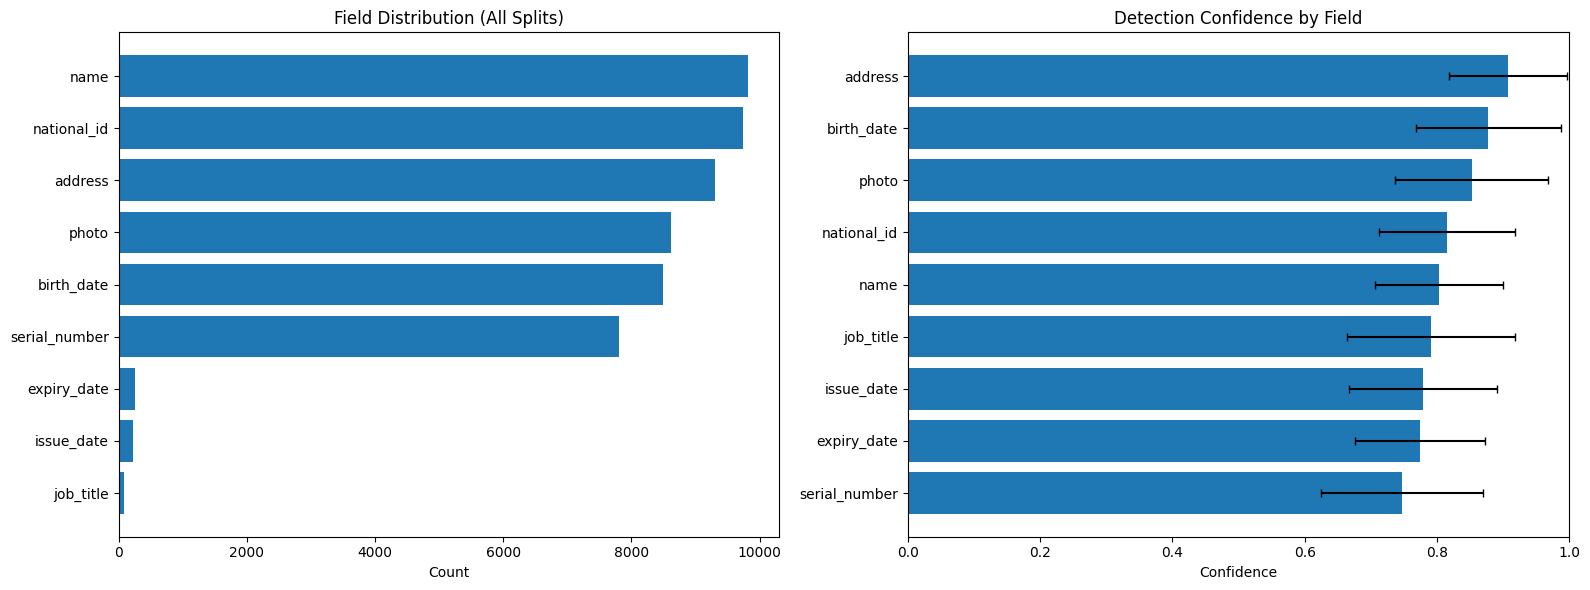

In [18]:
# Visualize field distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall field distribution
field_counts = df_full['field'].value_counts()
axes[0].barh(field_counts.index, field_counts.values)
axes[0].set_xlabel('Count')
axes[0].set_title('Field Distribution (All Splits)')
axes[0].invert_yaxis()

# Confidence distribution by field
conf_by_field = df_full.groupby('field')['confidence'].agg(['mean', 'std']).sort_values('mean', ascending=False)
axes[1].barh(conf_by_field.index, conf_by_field['mean'], xerr=conf_by_field['std'], capsize=3)
axes[1].set_xlabel('Confidence')
axes[1].set_title('Detection Confidence by Field')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [19]:
# Check output files
output_dir = ROOT / "rec" / "images" / "two_stage"
if output_dir.exists():
    crop_files = list(output_dir.glob("*.jpg"))
    print(f"📂 Cropped Fields Directory:")
    print(f"   Location: {output_dir}")
    print(f"   Total files: {len(crop_files):,}")
    
    # Sample files
    print(f"\n   Sample files:")
    for f in sorted(crop_files)[:5]:
        print(f"      - {f.name}")
else:
    print(f"⚠️  Output directory not found: {output_dir}")
    print("   Run the processing script first:")
    print("   python scripts/process_full_dataset_two_stage.py")

📂 Cropped Fields Directory:
   Location: /home/think/project/egyption_id_ready/rec/images/two_stage
   Total files: 112,038

   Sample files:
      - -_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec_address.jpg
      - -_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec_birth_date.jpg
      - -_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec_name.jpg
      - -_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec_national_id.jpg
      - -_jpeg.rf.5e7edc7a3e920e7b86ed83fdb897a3ec_photo.jpg


## 10. Next Steps


In [20]:
print("=" * 60)
print("🚀 NEXT STEPS")
print("=" * 60)
print()
print("✅ Two-stage detection complete!")
print()
print("📋 What you have:")
print(f"   - {len(df_full):,} field crops")
print(f"   - Metadata: crops_metadata_two_stage.csv")
print(f"   - Crops location: rec/images/two_stage/")
print()
print("📝 Now label the crops with OCR:")
print()
print("   # Use QARI OCR (recommended)")
print("   python scripts/label_crops.py --method qari-airllm")
print()
print("   # Or use Bakri OCR")
print("   python scripts/label_crops.py --method bakri-airllm")
print()
print("   # Or use both for comparison")
print("   python scripts/label_crops.py --method both")
print()
print("📚 Then continue with:")
print("   1. Notebook 02: Label and Train (02_label_and_train.ipynb)")
print("   2. Notebook 03: Evaluate and Deploy (03_evaluate_and_deploy.ipynb)")
print()
print("📖 Documentation:")
print("   - docs/PROCESSING_RESULTS.md - Full processing results")
print("   - docs/CLASS_MAPPING.md - Class mapping reference")
print("   - docs/NASO7Y_CLASSES.md - NASO7Y model classes")
print("=" * 60)

🚀 NEXT STEPS

✅ Two-stage detection complete!

📋 What you have:
   - 54,353 field crops
   - Metadata: crops_metadata_two_stage.csv
   - Crops location: rec/images/two_stage/

📝 Now label the crops with OCR:

   # Use QARI OCR (recommended)
   python scripts/label_crops.py --method qari-airllm

   # Or use Bakri OCR
   python scripts/label_crops.py --method bakri-airllm

   # Or use both for comparison
   python scripts/label_crops.py --method both

📚 Then continue with:
   1. Notebook 02: Label and Train (02_label_and_train.ipynb)
   2. Notebook 03: Evaluate and Deploy (03_evaluate_and_deploy.ipynb)

📖 Documentation:
   - docs/PROCESSING_RESULTS.md - Full processing results
   - docs/CLASS_MAPPING.md - Class mapping reference
   - docs/NASO7Y_CLASSES.md - NASO7Y model classes
